# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b> 07 - CNN - Cat & Dog- Transfer Learning ResNet152 - Automatic rescaling </b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

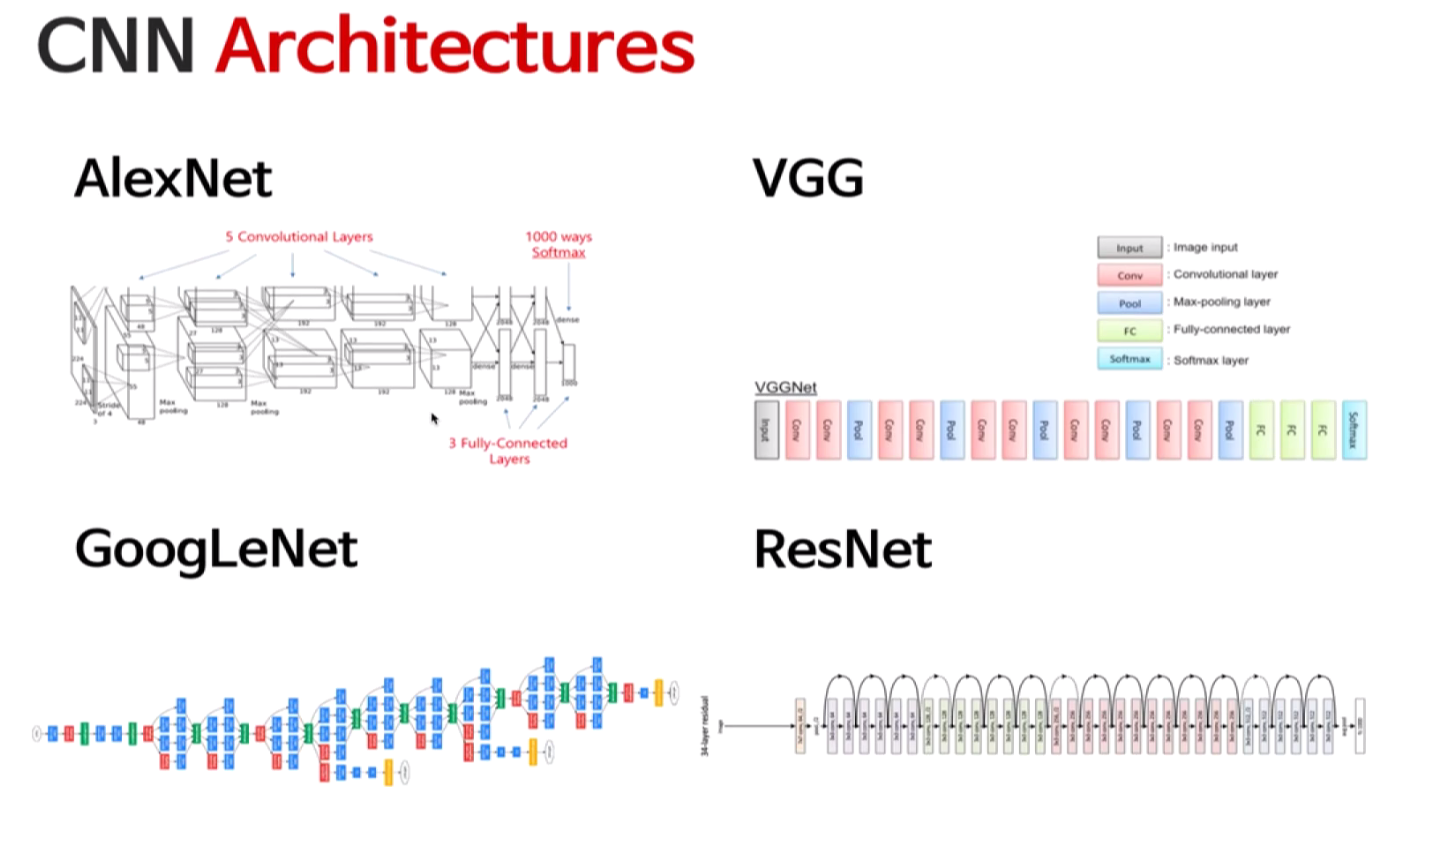

In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [2]:
pwd

'C:\\Users\\jawed\\Desktop\\B356\\Deep Learning\\Notebooks\\06- Transfer Learning-Cat&Dogs'

The Dogs vs. Cats dataset is a common computer vision dataset in which pictures are classified as either including a dog or a cat.

After the dataset is well studied, it can be used to understand and practice how to design, evaluate, and apply convolutional neural networks for image classification.

You will build a classifier with images and try to detect dogs versus cats using CNN.

Train set includes 12500 cat-5026 dog images, validation set includes 1219 cat-1071 dog images and test set incgludes 6897 cat and dogs images together. 

In [3]:
my_data_dir='datam/'

In [4]:
os.listdir(my_data_dir)

['test', 'train']

In [5]:
train_path = my_data_dir+'train'
test_path = my_data_dir+'test'

In [6]:
os.listdir(train_path)

['cat', 'dog']

**Let's check how many images there are.**

In [7]:
len(os.listdir(train_path+'/cat'))

12500

In [8]:
len(os.listdir(train_path+'/dog'))

5026

In [9]:
os.listdir(train_path+'/cat')[0]

'cat.0.jpg'

In [10]:
path1=train_path+'/cat'+'/cat.1000.jpg'
path2=train_path+'/dog'+'/dog.1000.jpg'

In [11]:
cat_img=imread(path1)
dog_img=imread(path2)

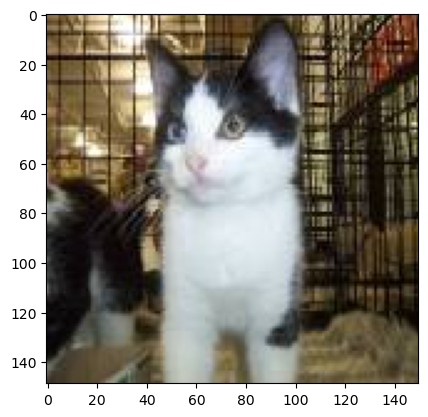

In [12]:
plt.imshow(cat_img)

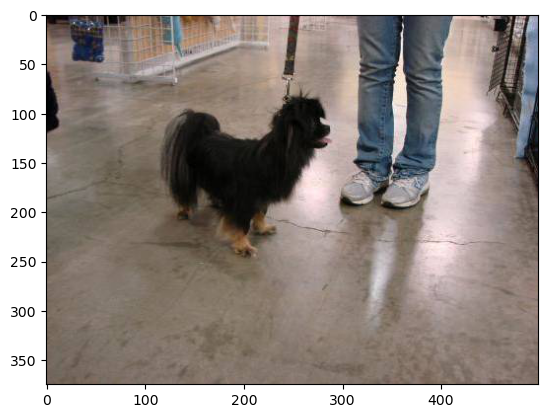

In [13]:
plt.imshow(dog_img)

**Let's decide on the final dimension of these images.**

In [14]:
cat_img.max()

255

In [15]:
cat_img.min()

0

In [16]:
cat_img.shape

(149, 150, 3)

In [17]:
dog_img.shape

(375, 499, 3)

In [18]:
x= []
y = []
for image in os.listdir(train_path+'/cat'):
    
    img = imread(train_path+'/cat/'+image)
    d1,d2,colors = img.shape
    x.append(d1)
    y.append(d2)

C:\Users\jawed\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\jawed\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<Axes: >

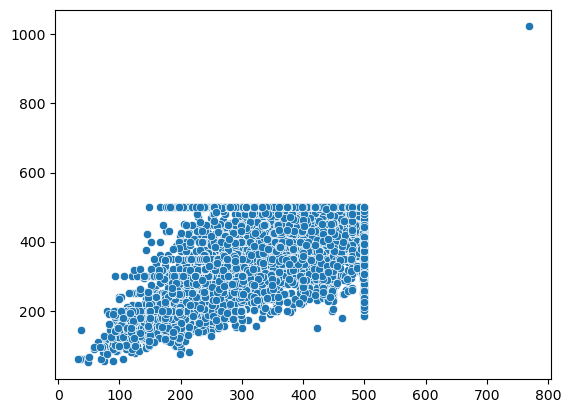

In [19]:
sns.scatterplot(x=x,y=y)

In [20]:

np.mean(x)

356.46712

In [21]:
np.mean(y)

410.52264

In [22]:
image_shape = (224, 224,3)

In [23]:
# help(ImageDataGenerator)

**Image Manipulation**

We can use the ImageDataGenerator to manipulate the images with rotation, resizing, and scaling so the model becomes more robust to different images that our data set doesn't have. ImageDataGenerator does the followings.

* Accepts a batch of images used for training.
* Applies a series of random transformations to each image in the batch.
* Replaces the original batch with randomly transformed batch.
* Training the CNN on this randomly transformed batch.

The goal of applying data augmentation is to have a more generalized model.

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.resnet import preprocess_input # For preprocessing (rescaling için)

In [25]:
image_gen = ImageDataGenerator(rotation_range=20, # rotate the image 20 degrees
                               width_shift_range=0.10, # Shift the pic width by a max of 10%
                               height_shift_range=0.10, # Shift the pic height by a max of 10%
                               
                               # rescale=1/255, # Rescale the image by normalzing it.
                               preprocessing_function=preprocess_input,  # Apply ResNet preprocessing here - ISMET - ResNet in işlemini enjekte ediyor, dataları donusturuyor
                               
                               shear_range=0.1, # Shear means cutting away part of the image (max 10%)
                               zoom_range=0.1, # Zoom in by 10% max
                               horizontal_flip=True, # Allo horizontal flipping
                               fill_mode='nearest' # Fill in missing pixels with the nearest filled value
                              )

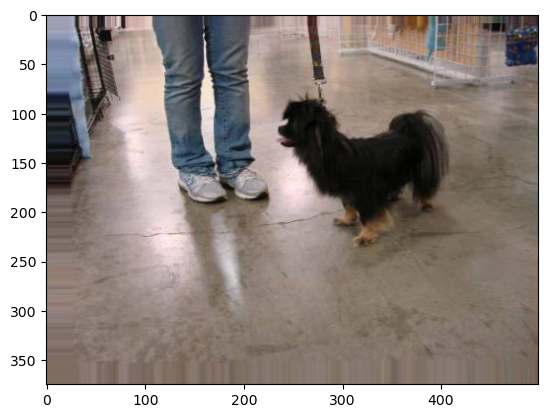

In [26]:
plt.imshow(image_gen.random_transform(dog_img))

image_gen.flow_from_directory(train_path)

# Creating the Model

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.applications.resnet import ResNet152, preprocess_input, decode_predictions

In transfer learning models; 

1) **include_top=False** --> We are setting up the ANN part.

2) **weights= "imagenet"** --> Use the weights learned while training on imageNet data.

3) **layer.trainable=False** --> The model doesn't trained from scratch, the weights it has previously learned should be used.

Alttaki kod:

ResNet152 önceden eğitilmiş CNN modelini (ImageNet verisiyle eğitilmiş) temel alıyor, ancak sondaki sınıflandırma katmanlarını kaldırıyor (include_top=False).

Bu modelin ağırlıklarını donduruyor (trainable=False), yani önceden öğrenilmiş özellikler sabit kalacak, yeniden eğitilmeyecek.

Bu önceden eğitilmiş modelin çıktısını Flatten (düzleştirme) katmanıyla 1 boyutlu hale getiriyor.

Ardından 64 nöronlu bir gizli tam bağlı (Dense) katman ekliyor ve aktivasyon fonksiyonu olarak ReLU kullanıyor.

Son olarak 1 nöronlu sigmoid aktivasyonlu bir çıkış katmanı ekleyerek ikili sınıflandırma için model oluşturuyor.

Modeli binary_crossentropy kaybı ve adam optimizasyonu ile derliyor ve doğruluk metriğini izliyor.

In [28]:
resnet_model = Sequential()

pretrained_model= tf.keras.applications.ResNet152(include_top=False,  # ANN i ben kuracağım demektir
                   input_shape=image_shape,
                   pooling='avg',    # ResNet152 de "avg" kullanmak yaygındır
                   weights= "imagenet")

for layer in pretrained_model.layers:
        layer.trainable=False  # Modeli tekrar train etmeyin demektir !.

resnet_model.add(pretrained_model)

# Flatten
resnet_model.add(Flatten())

# ANN
# Hidden Layer
resnet_model.add(Dense(64, activation='relu'))

# Output layer
resnet_model.add(Dense(1, activation='sigmoid'))

# Compile the Model
resnet_model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [29]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet152 (Functional)      (None, 2048)              58370944  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 64)                131136    
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 58502145 (223.17 MB)
Trainable params: 131201 (512.50 KB)
Non-trainable params: 58370944 (222.67 MB)
_________________________________________________________________


## Early Stopping

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

In [32]:
batch_size = 64

### I applied imeage generation on just train data

In [33]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(224, 224),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True)

Found 17526 images belonging to 2 classes.


### I didn't apply imeage generation on test data

In [34]:
image_gen_test = ImageDataGenerator(preprocessing_function=preprocess_input) # Automatic preproessing on test data

test_image_gen = image_gen_test.flow_from_directory(test_path,

                                                   target_size=(224, 224),
                                                   
                                                   color_mode='rgb',
                                                   
                                                   batch_size=batch_size,
                                                   
                                                   class_mode='binary', shuffle=False)

Found 2290 images belonging to 2 classes.


Üstteki kod, test verisini model için hazırlar:

Görüntüleri doğru boyuta getirir,

Önceden eğitilmiş modele uygun şekilde ön işler,

Etiketleri ikili sınıf olarak ayarlar,

Veriyi belleğe yüklerken sırasını korur.

Bu sayede test verisi doğrudan modelde tahmin veya değerlendirme için kullanılabilir.

## Model Training

In [35]:
results = resnet_model.fit(train_image_gen,epochs=5,
                    validation_data=test_image_gen,
                    callbacks=[early_stop])


# Uyarı gelirse dikkate almayın

Epoch 1/5


274/274 [==============================] - 2144s 8s/step - loss: 0.0490 - accuracy: 0.9833 - val_loss: 0.1952 - val_accuracy: 0.9721
Epoch 2/5
274/274 [==============================] - 2124s 8s/step - loss: 0.0316 - accuracy: 0.9895 - val_loss: 0.2077 - val_accuracy: 0.9686
Epoch 3/5
274/274 [==============================] - 2080s 8s/step - loss: 0.0268 - accuracy: 0.9913 - val_loss: 0.1924 - val_accuracy: 0.9721
Epoch 4/5
274/274 [==============================] - 2071s 8s/step - loss: 0.0219 - accuracy: 0.9934 - val_loss: 0.2199 - val_accuracy: 0.9699
Epoch 5/5
274/274 [==============================] - 2065s 8s/step - loss: 0.0212 - accuracy: 0.9919 - val_loss: 0.2041 - val_accuracy: 0.9707


# Evaluating the Model

In [36]:
summary = pd.DataFrame(resnet_model.history.history)
summary.head()

,loss,accuracy,val_loss,val_accuracy
0,0.048992,0.983282,0.195204,0.972052
1,0.031573,0.989501,0.207745,0.968559
2,0.026779,0.991270,0.192369,0.972052
3,0.021944,0.993438,0.219917,0.969869
4,0.021158,0.991898,0.204066,0.970742


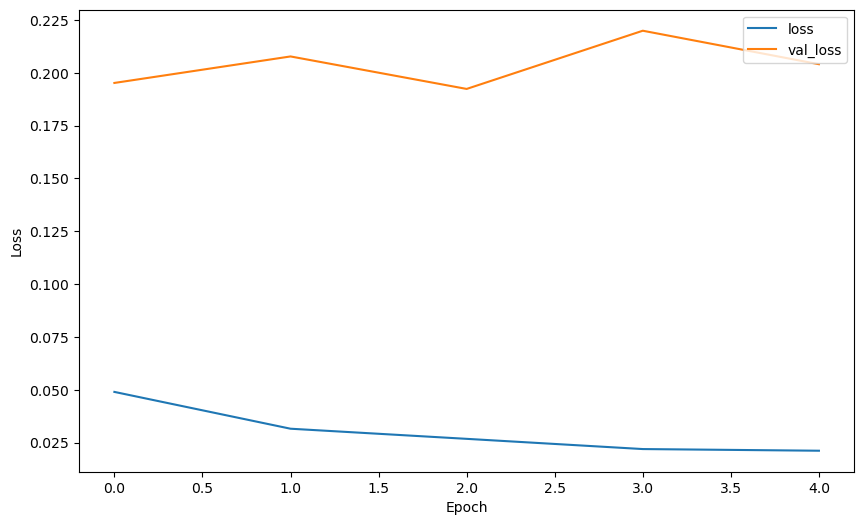

In [37]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

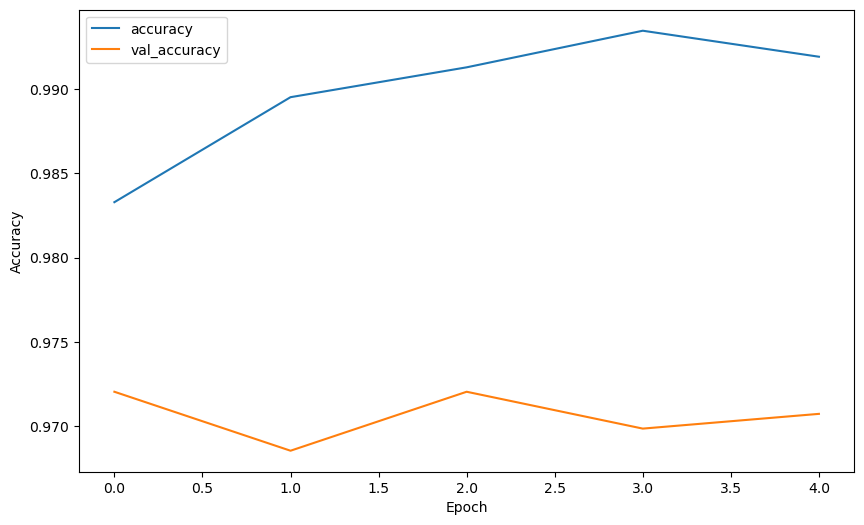

In [38]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [39]:
resnet_model.metrics_names  # kullanılan metrikler

['loss', 'accuracy']

In [41]:
resnet_model.evaluate(test_image_gen)

36/36 [==============================] - 248s 7s/step - loss: 0.2041 - accuracy: 0.9707


[0.20406591892242432, 0.9707423448562622]

In [42]:
pred_probabilities = resnet_model.predict(test_image_gen)

36/36 [==============================] - 242s 7s/step


In [43]:
pred_probabilities

array([[6.9474063e-06],
       [1.1686806e-03],
       [1.0925694e-06],
       ...,
       [9.9996620e-01],
       [9.9999958e-01],
       [9.9999070e-01]], dtype=float32)

In [44]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [45]:
predictions = pred_probabilities > 0.5

In [46]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

In [47]:
from sklearn.metrics import classification_report,confusion_matrix

In [48]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1219
           1       0.98      0.96      0.97      1071

    accuracy                           0.97      2290
   macro avg       0.97      0.97      0.97      2290
weighted avg       0.97      0.97      0.97      2290



In [49]:
confusion_matrix(test_image_gen.classes,predictions)

array([[1195,   24],
       [  43, 1028]], dtype=int64)